In [1]:
import pandas as pd
import os
import re
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#get the parent directory
cwd = os.getcwd()
parent = os.path.normpath(os.path.join(cwd, '..', '..'))
path_AMO = parent + '/AutomaticMusicOrchestration'
model_path = path_AMO + '/'

results_dir = model_path + "results"
plots_dir = model_path + "plots"

In [3]:
# Metrics
df = pd.read_csv(os.path.join(results_dir, f"metrics (multi-label).csv"))

# Reconstruct dictionaries if needed
metrics_mean = defaultdict(list)
metrics_std = defaultdict(list)

for _, row in df.iterrows():
    metrics_mean[row["metric"]].append(row["mean"])
    metrics_std[row["metric"]].append(row["std"])

# Convert back to normal dicts
metrics_mean = dict(metrics_mean)
metrics_std = dict(metrics_std)

# Extract metric names
ml_metrics_names = df["metric"].drop_duplicates().tolist()

In [4]:
figsize_x, figsize_y = 13, 3
ylim_a, ylim_b = 0, 1.3
fontsize = 8

In [5]:
# Model names
df = pd.read_csv(os.path.join(results_dir, "model_names (multi-label).csv"))

model_names = df["model_name"].tolist()
model_names_short = df["model_name_short"].tolist()

In [6]:
def transform_transpose_text(text):
    pattern = r"transpose_\{'n_semitones':\s*([+-]?\d+)\}"
    
    def repl(match):
        n = int(match.group(1))
        direction = "down" if n < 0 else "up"
        return f"transposition {direction} by {abs(n)} semitones"
    
    return re.sub(pattern, repl, text)

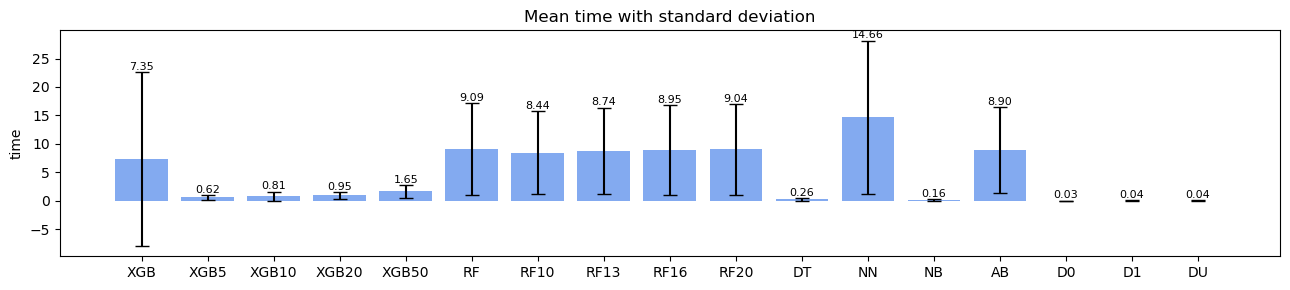

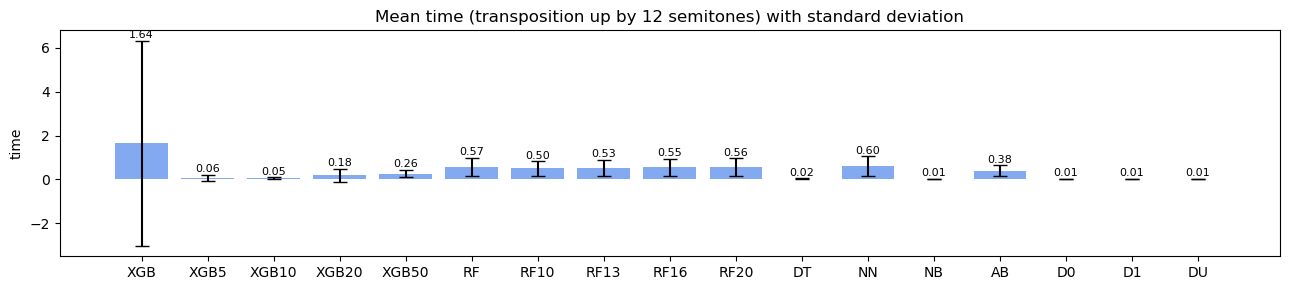

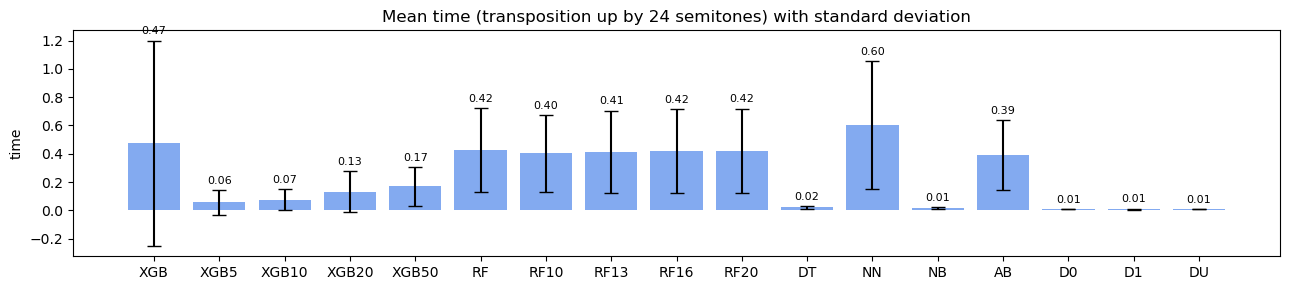

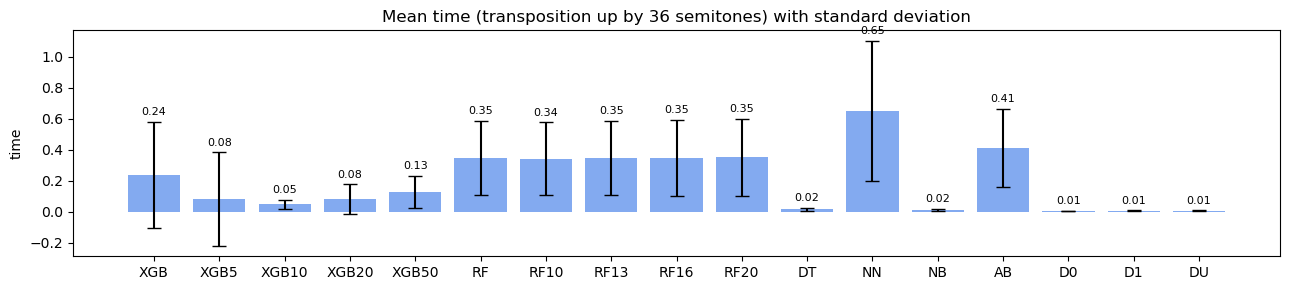

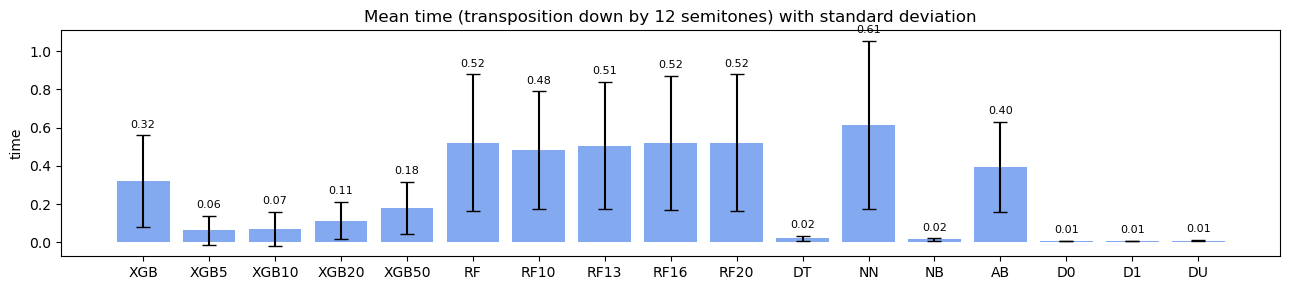

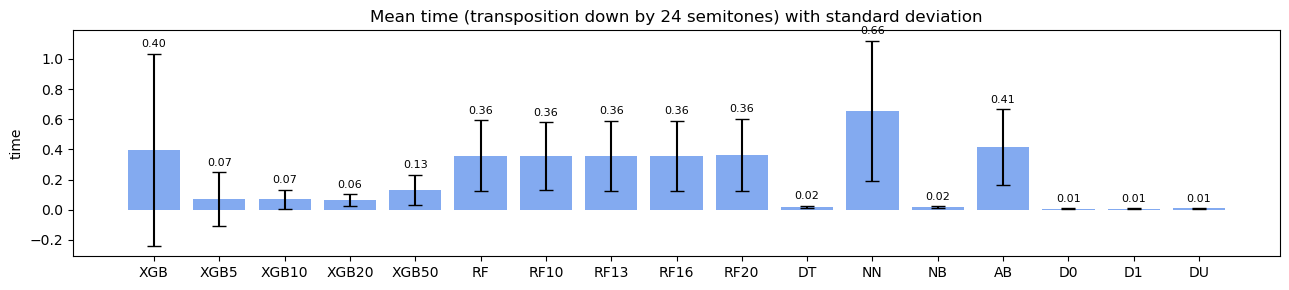

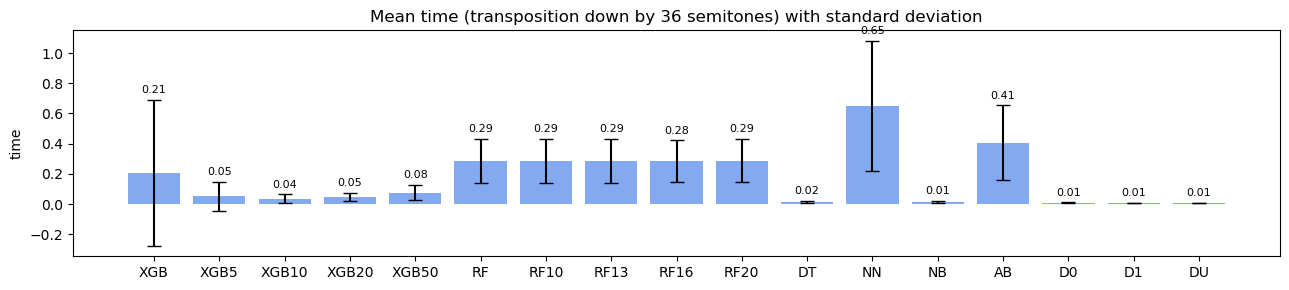

In [7]:
for mn in ml_metrics_names:
    if "time" in mn:
        # Plot
        plt.figure(figsize=(figsize_x, figsize_y))
        barlist = plt.bar(model_names_short, metrics_mean[mn], yerr=metrics_std[mn], capsize=5, color='cornflowerblue', alpha=0.8)

        ylabel = re.sub(r"\([^)]*\)", "", mn).strip()
        plt.ylabel(ylabel)
        plt.title(f'Mean {transform_transpose_text(mn)} with standard deviation')
        if "time" not in mn:
            plt.ylim(ylim_a, ylim_b)
            ax = plt.gca()
            ticks = ax.get_yticks()
            ax.set_yticks([t for t in ticks if t <= 1])

        # Optional: Add mean values above bars
        for i, (mean, std) in enumerate(zip(metrics_mean[mn], metrics_std[mn])):
            plt.text(i, mean + std + 0.03, f"{mean:.2f}", ha='center', va='bottom', fontsize=fontsize)

        os.makedirs(plots_dir, exist_ok=True)

        #plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
        plt.tight_layout()

        plt.savefig(os.path.join(plots_dir, f"{transform_transpose_text(mn)} (multi-label).png"),
            dpi=300, bbox_inches="tight")
        plt.show()

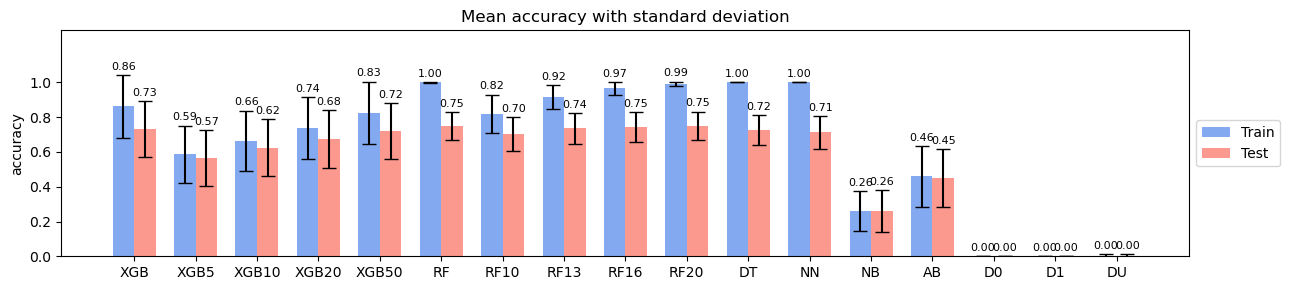

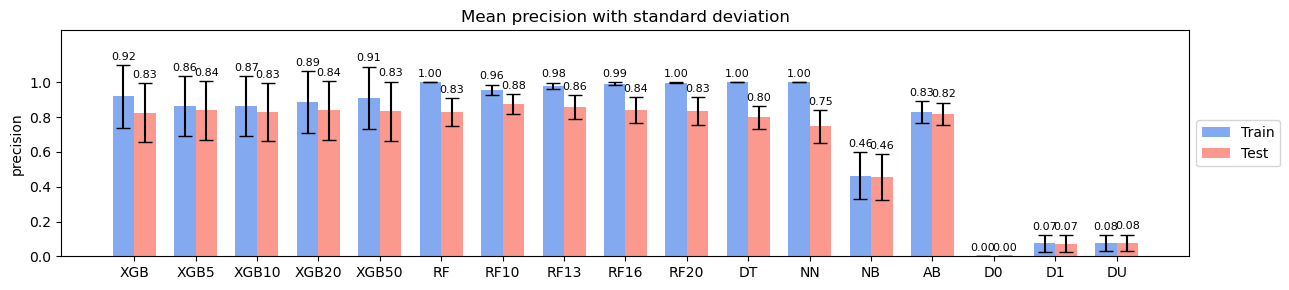

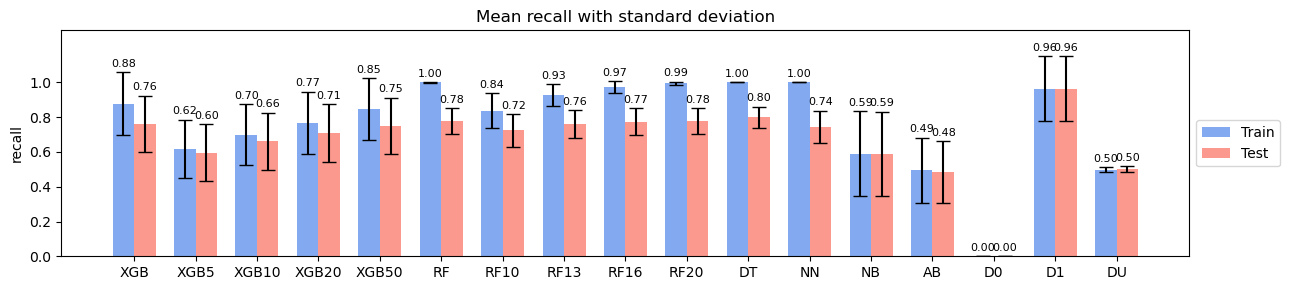

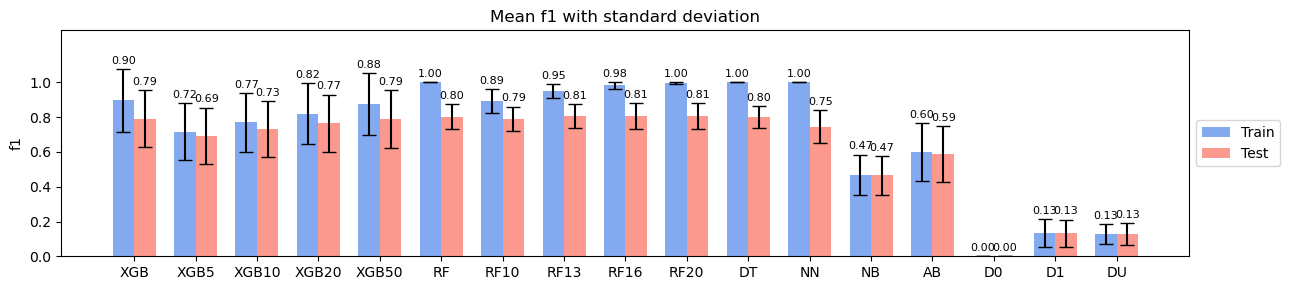

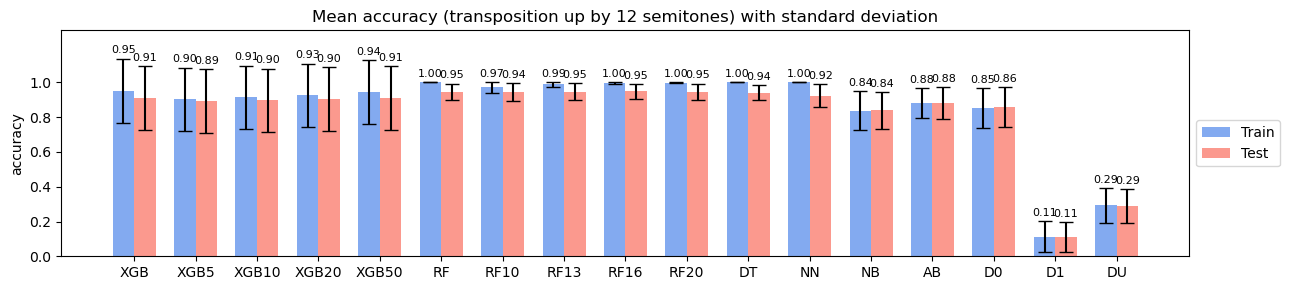

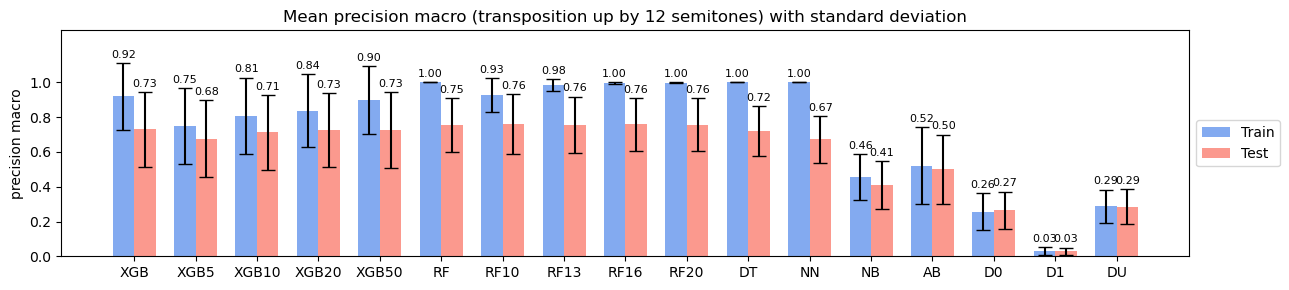

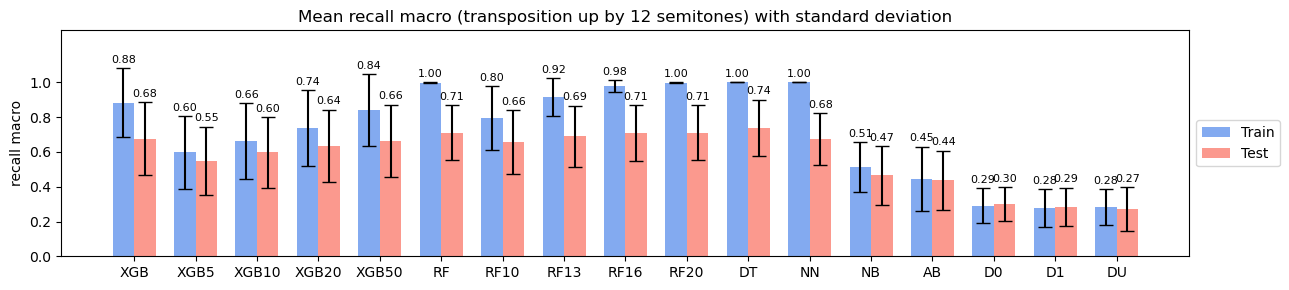

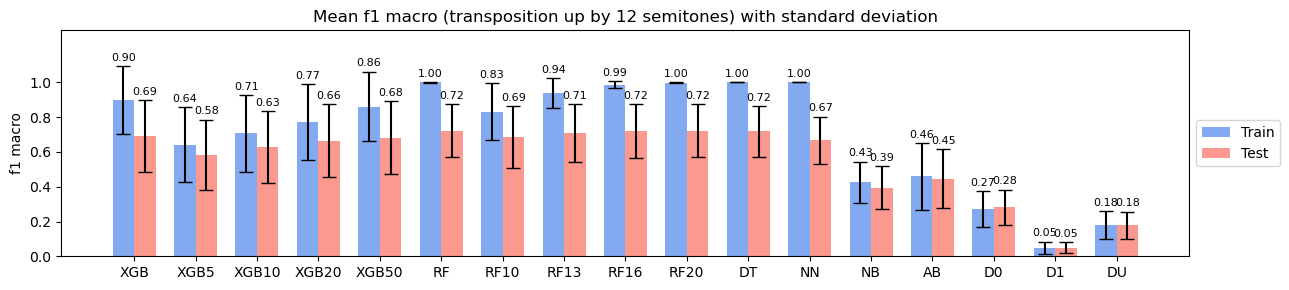

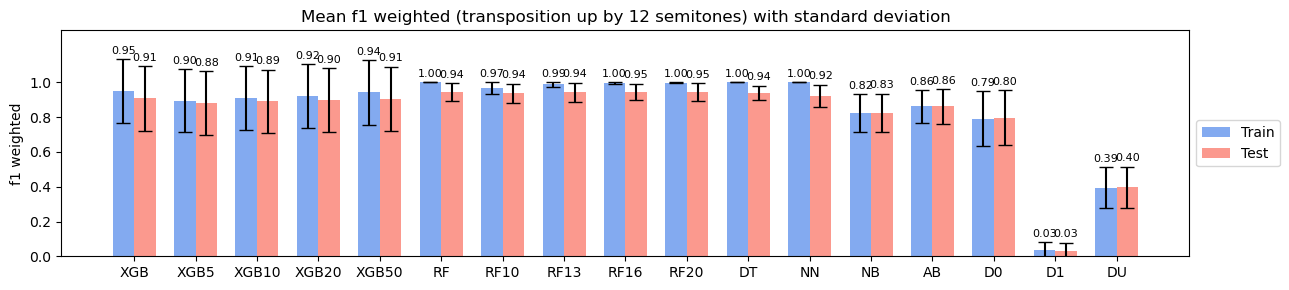

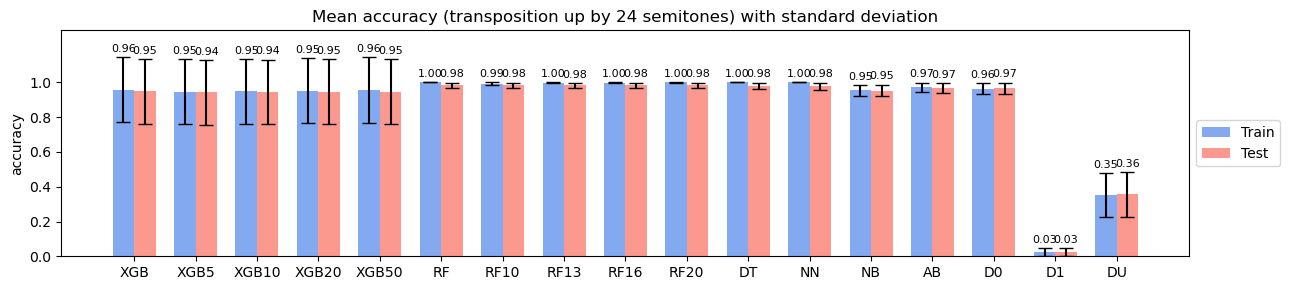

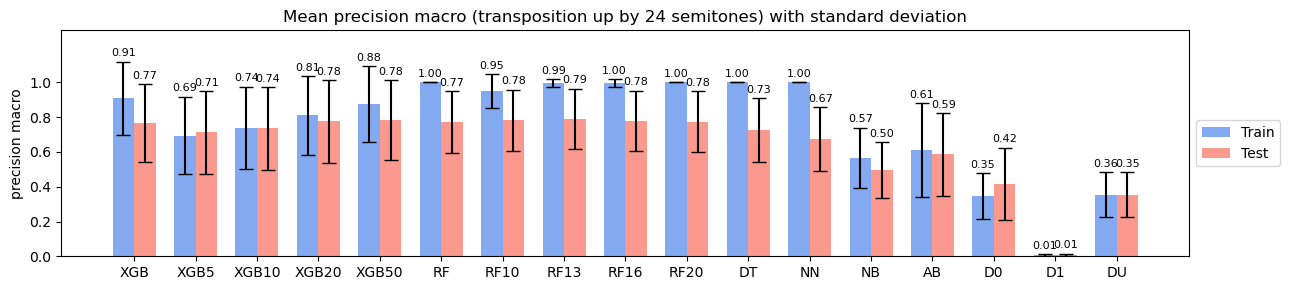

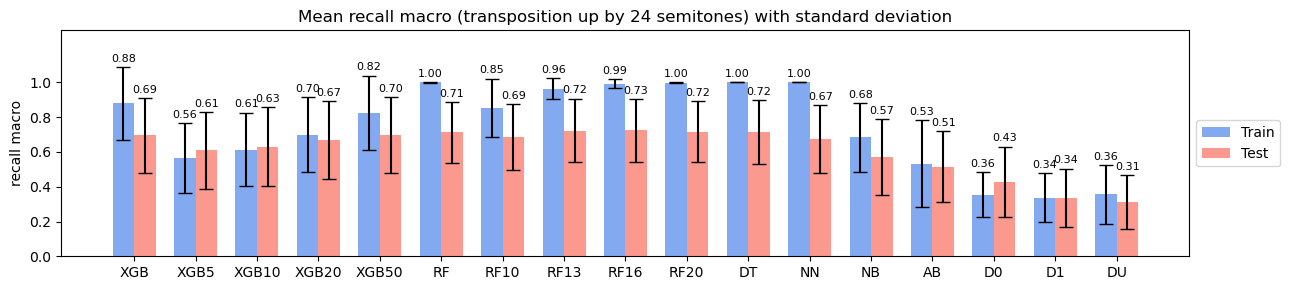

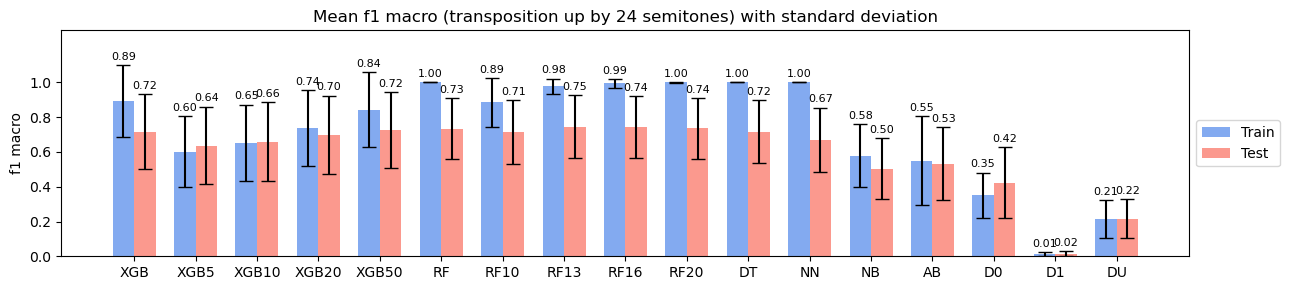

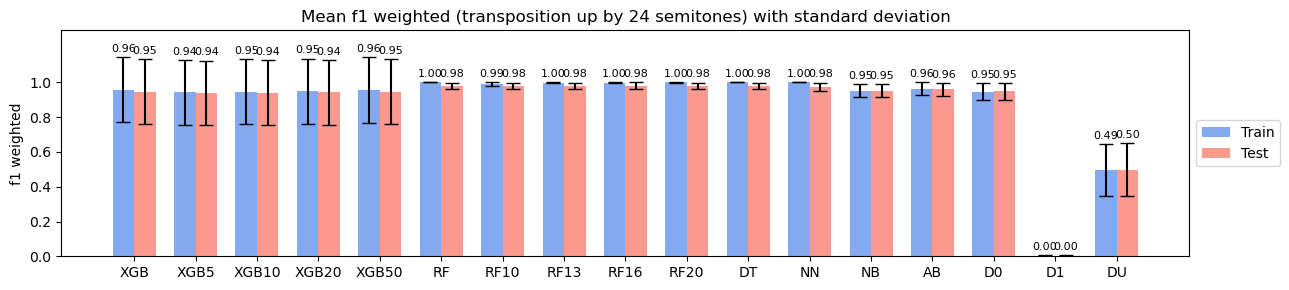

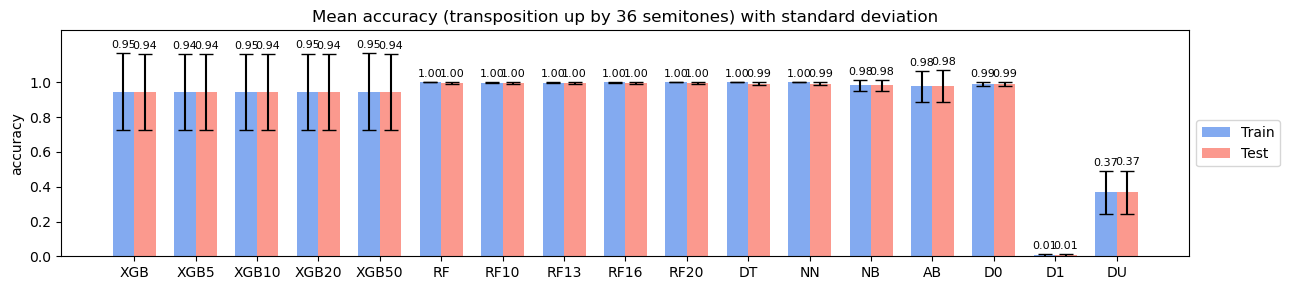

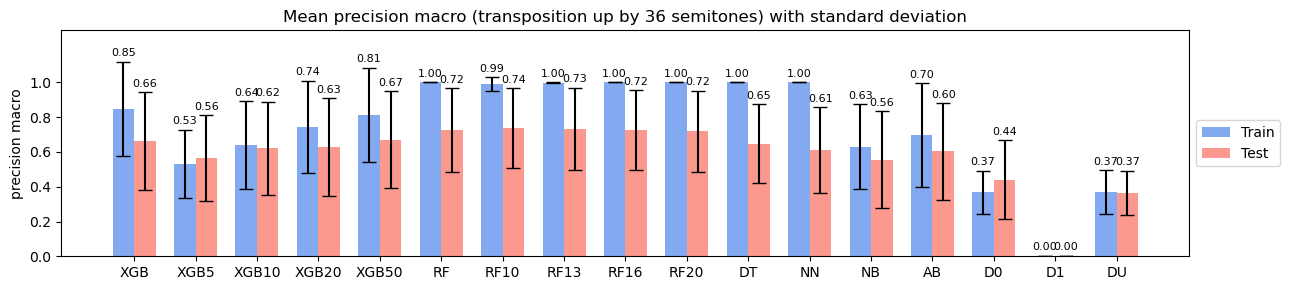

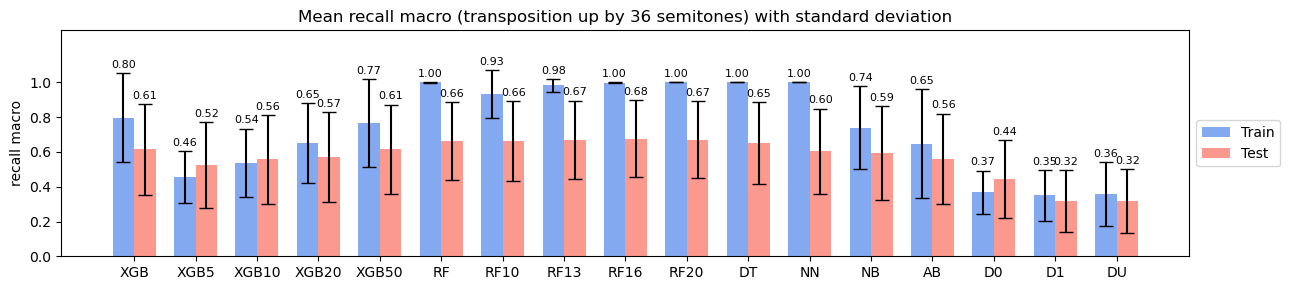

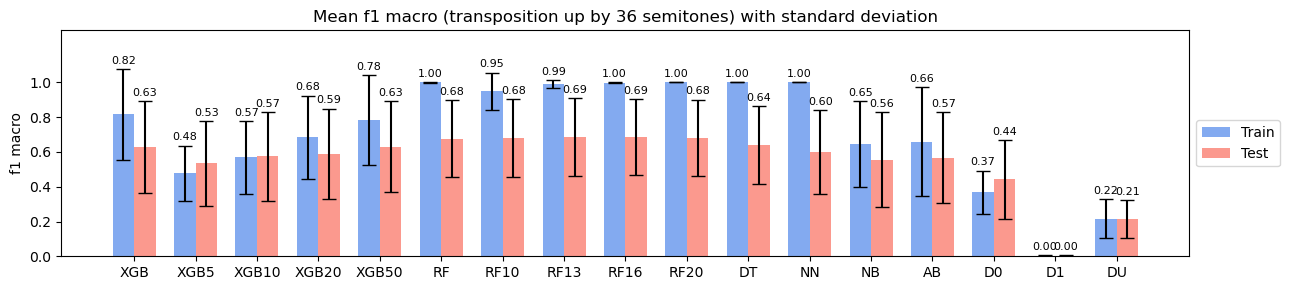

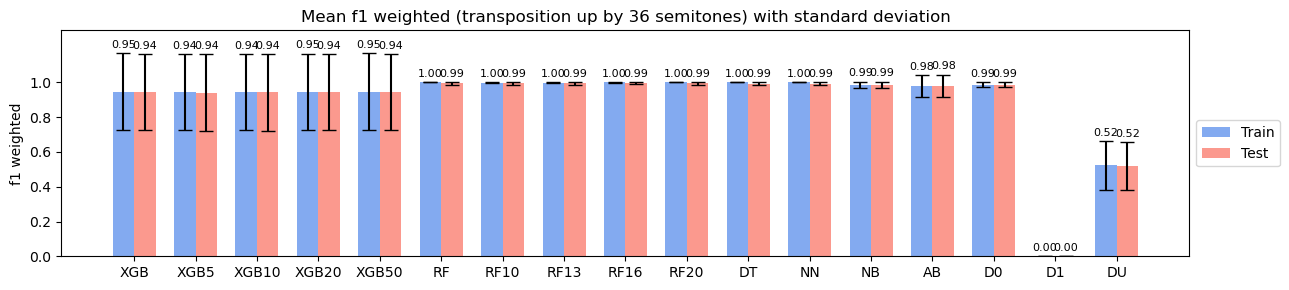

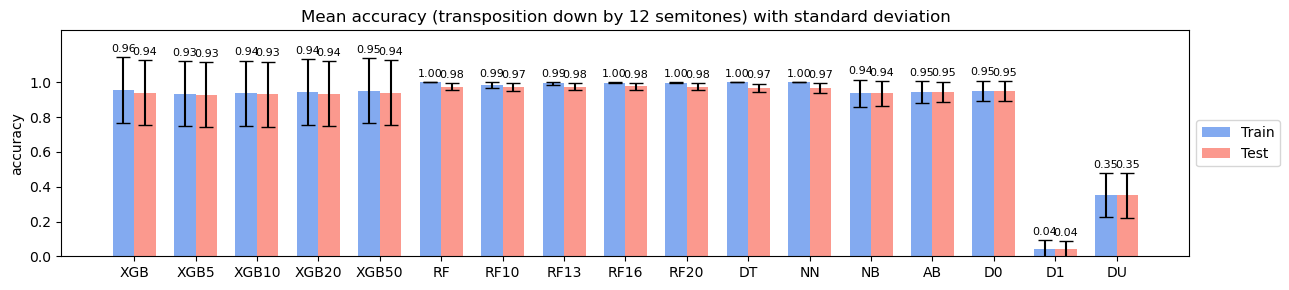

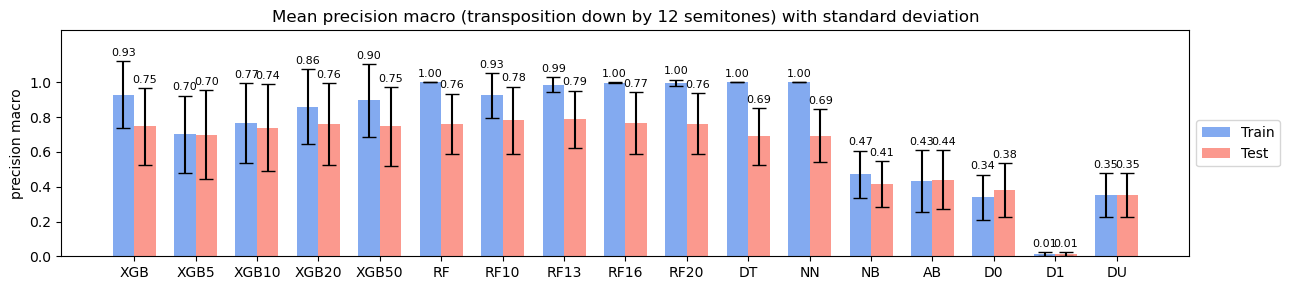

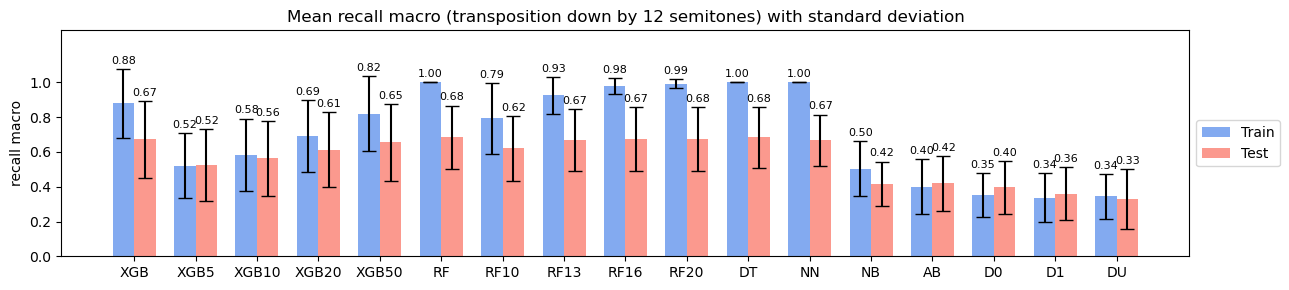

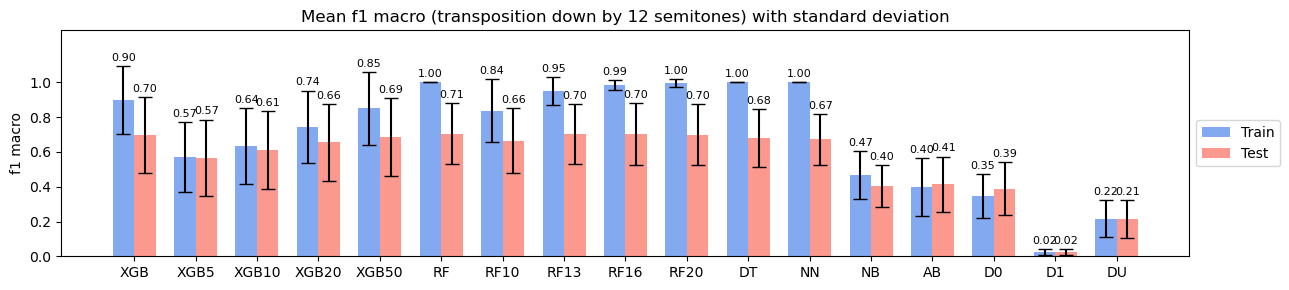

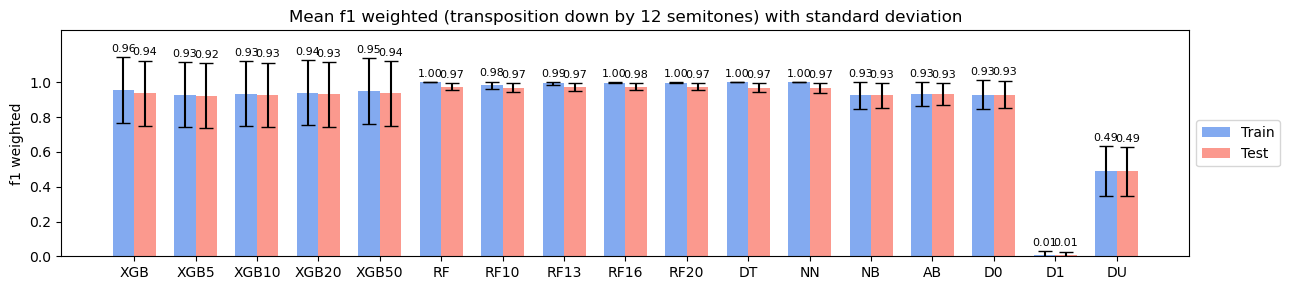

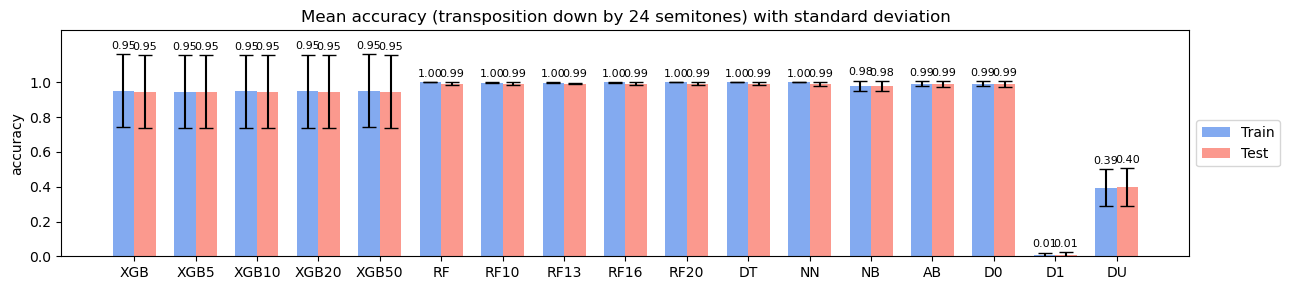

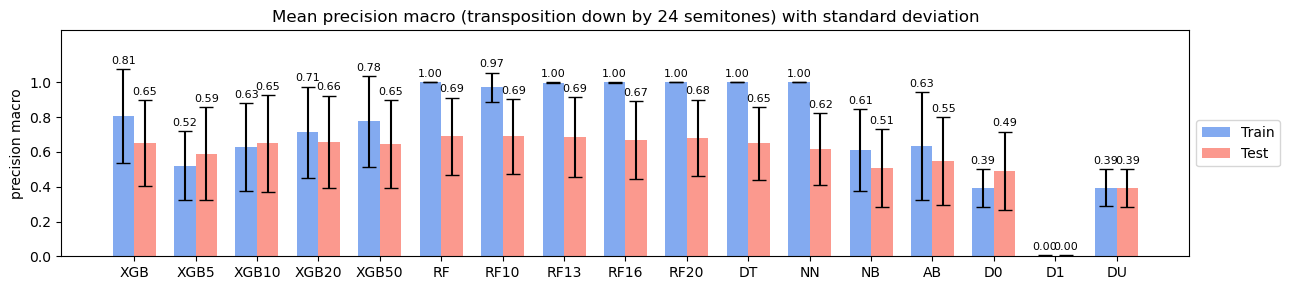

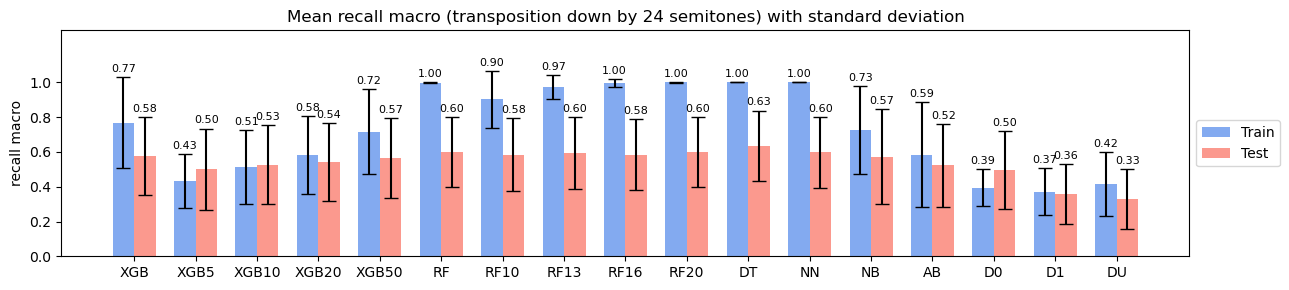

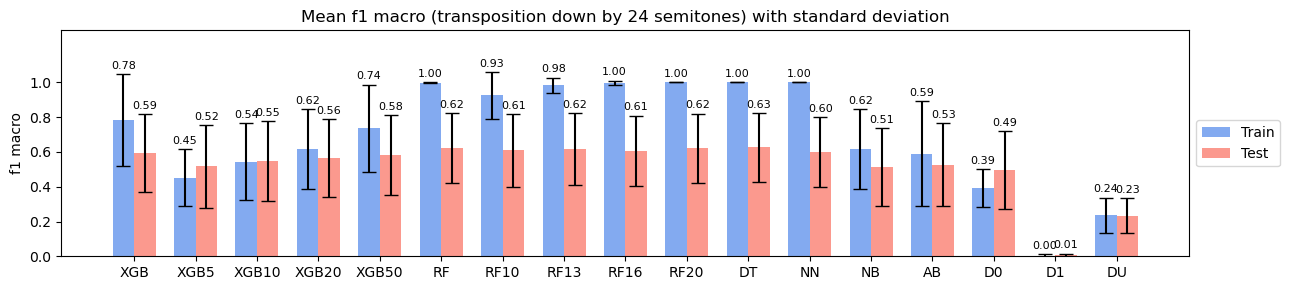

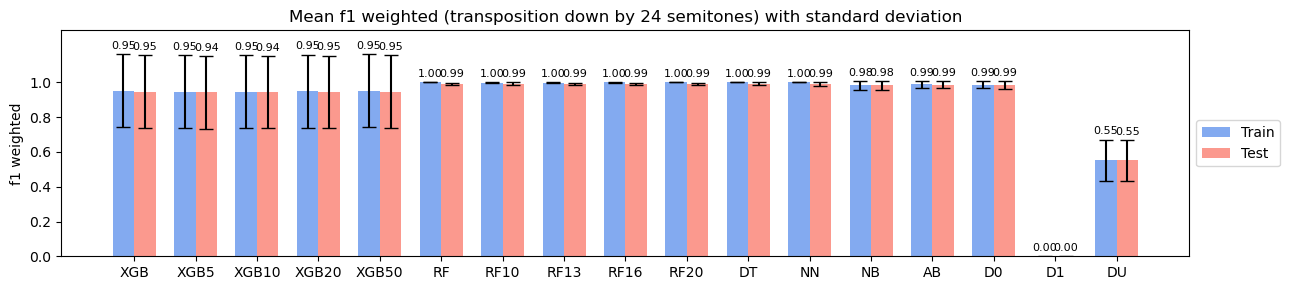

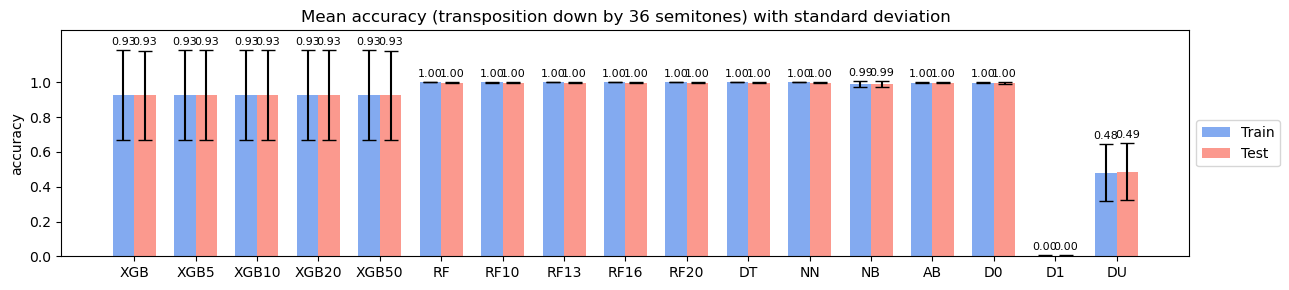

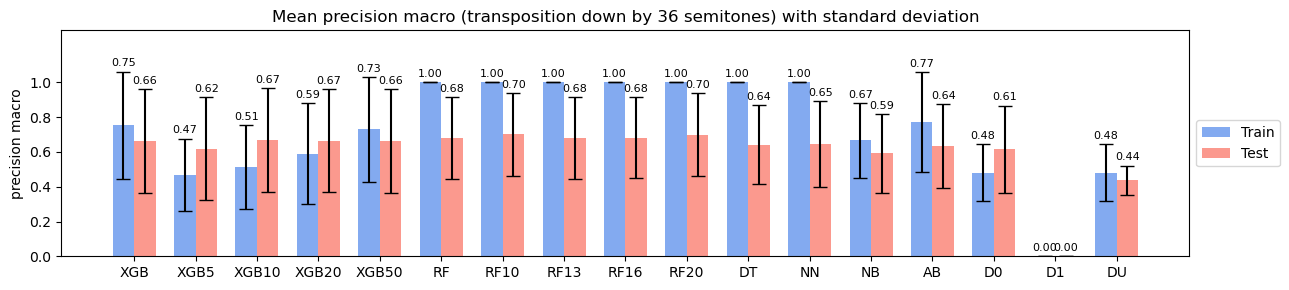

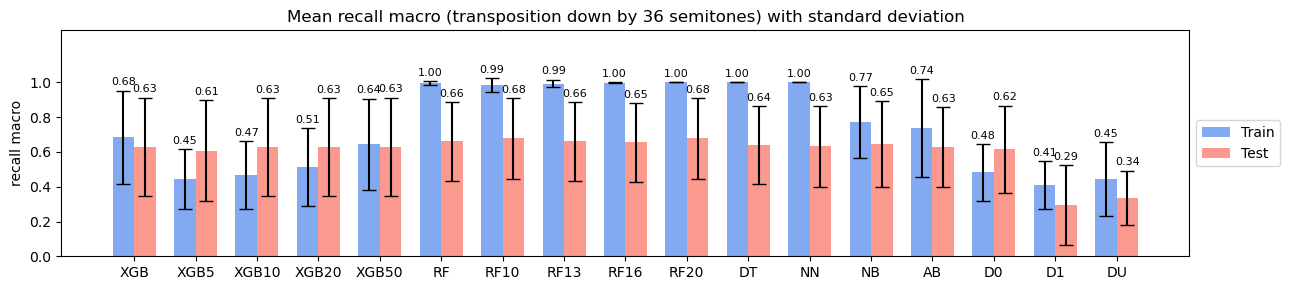

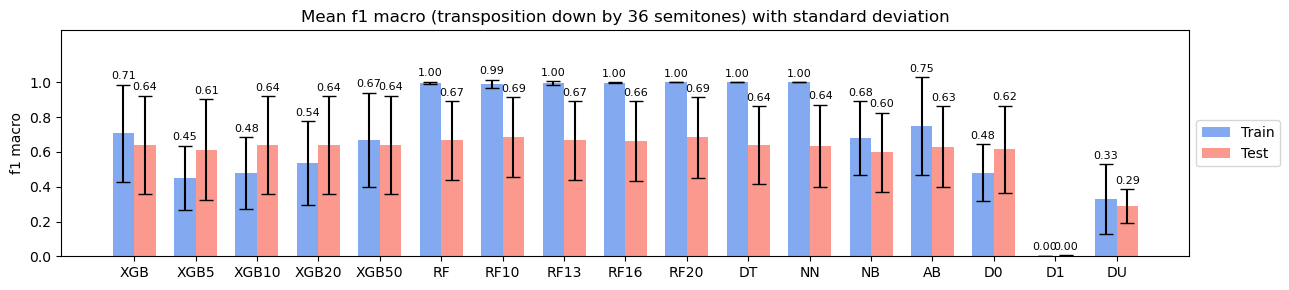

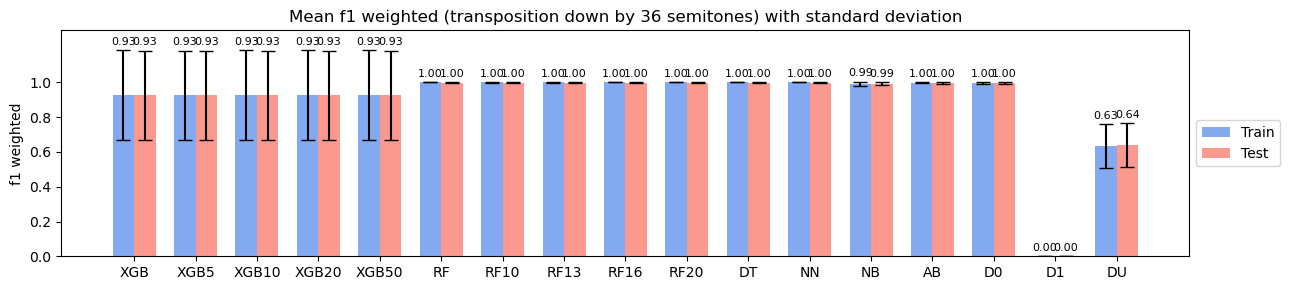

In [8]:
for mn in ml_metrics_names:
    if "train" in mn:
        mn_train = mn
        mn_test = mn.replace("train", "test")

        # Data for the two series
        train_means = metrics_mean[mn_train]
        test_means  = metrics_mean[mn_test]
        train_stds  = metrics_std[mn_train]
        test_stds   = metrics_std[mn_test]

        x = np.arange(len(model_names_short))   # positions
        width = 0.35

        plt.figure(figsize=(figsize_x, figsize_y))

        # Two bar groups
        plt.bar(x - width/2, train_means, width,
                yerr=train_stds, capsize=5,
                label='Train', color='cornflowerblue', alpha=0.8)

        plt.bar(x + width/2, test_means, width,
                yerr=test_stds, capsize=5,
                label='Test', color='salmon', alpha=0.8)

        # Labels & layout
        plt.xticks(x, model_names_short)
        title = mn.replace(" (train)", "")
        ylabel = re.sub(r"\([^)]*\)", "", title).strip()
        plt.ylabel(ylabel)
        plt.title(f'Mean {transform_transpose_text(title)} with standard deviation')

        if "time" not in mn:
            plt.ylim(ylim_a, ylim_b)
            ax = plt.gca()
            ticks = ax.get_yticks()
            ax.set_yticks([t for t in ticks if t <= 1])

        # Add mean value labels above bars
        for i, (mean, std) in enumerate(zip(train_means, train_stds)):
            plt.text(x[i] - width/2, mean + std + 0.03, f"{mean:.2f}",
                    ha='center', fontsize=fontsize)

        for i, (mean, std) in enumerate(zip(test_means, test_stds)):
            plt.text(x[i] + width/2, mean + std + 0.03, f"{mean:.2f}",
                    ha='center', fontsize=fontsize)
            
    
        os.makedirs(plots_dir, exist_ok=True)

        plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
        plt.tight_layout()

        plt.savefig(os.path.join(plots_dir, f"{transform_transpose_text(title)} (multi-label).png"),
            dpi=300, bbox_inches="tight")
        plt.show()

In [9]:
# Metrics
df = pd.read_csv(os.path.join(results_dir, f"metrics (single label).csv"))

# Reconstruct dictionaries if needed
metrics_mean = defaultdict(list)
metrics_std = defaultdict(list)

for _, row in df.iterrows():
    metrics_mean[row["metric"]].append(row["mean"])
    metrics_std[row["metric"]].append(row["std"])

# Convert back to normal dicts
metrics_mean = dict(metrics_mean)
metrics_std = dict(metrics_std)

# Extract metric names
ml_metrics_names = df["metric"].drop_duplicates().tolist()

In [10]:
# Model names
df = pd.read_csv(os.path.join(results_dir, "model_names (single label).csv"))

model_names = df["model_name"].tolist()
model_names_short = df["model_name_short"].tolist()

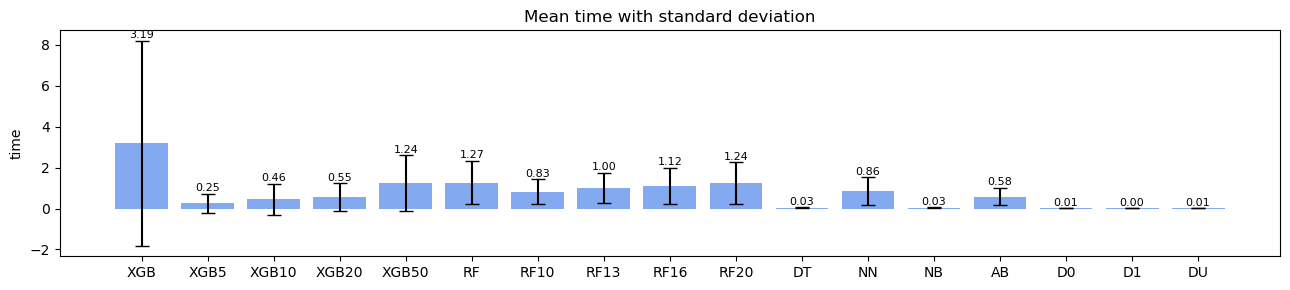

In [11]:
for mn in ml_metrics_names:
    if "time" in mn:
        # Plot
        plt.figure(figsize=(figsize_x, figsize_y))
        barlist = plt.bar(model_names_short, metrics_mean[mn], yerr=metrics_std[mn], capsize=5, color='cornflowerblue', alpha=0.8)

        ylabel = re.sub(r"\([^)]*\)", "", mn).strip()
        plt.ylabel(ylabel)
        plt.title(f'Mean {transform_transpose_text(mn)} with standard deviation')
        if "time" not in mn:
            plt.ylim(ylim_a, ylim_b)
            ax = plt.gca()
            ticks = ax.get_yticks()
            ax.set_yticks([t for t in ticks if t <= 1])

        # Optional: Add mean values above bars
        for i, (mean, std) in enumerate(zip(metrics_mean[mn], metrics_std[mn])):
            plt.text(i, mean + std + 0.03, f"{mean:.2f}", ha='center', va='bottom', fontsize=fontsize)

        os.makedirs(plots_dir, exist_ok=True)

        plt.tight_layout()

        plt.savefig(os.path.join(plots_dir, f"{transform_transpose_text(mn)} (single label).png"),
            dpi=300, bbox_inches="tight")
        plt.show()

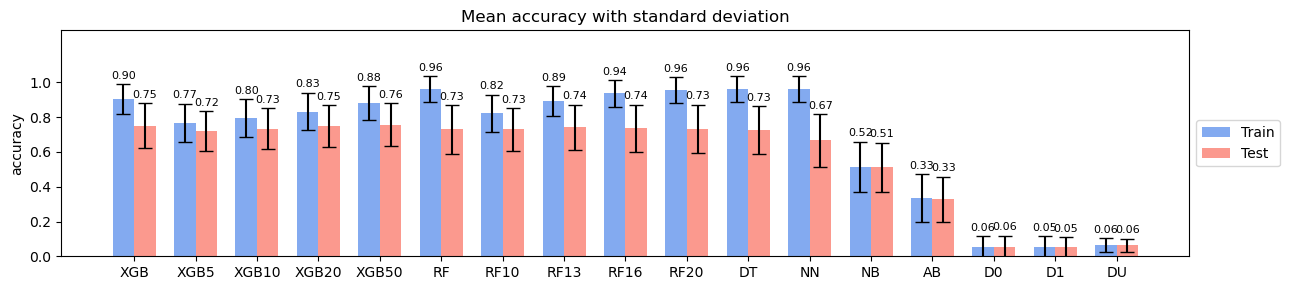

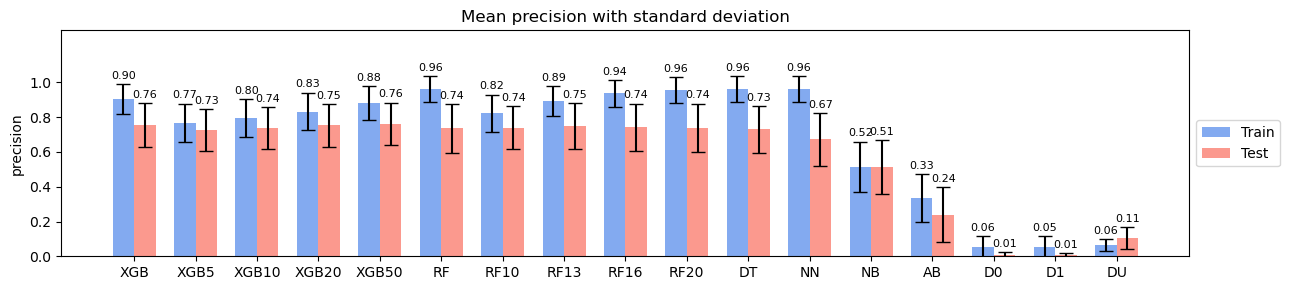

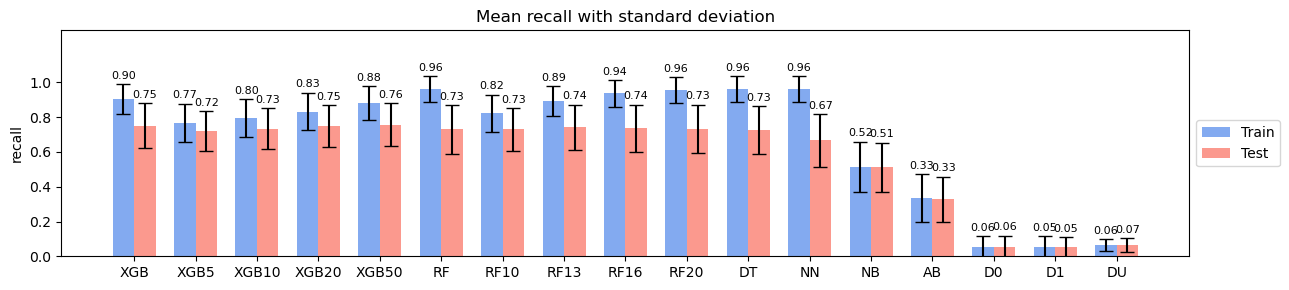

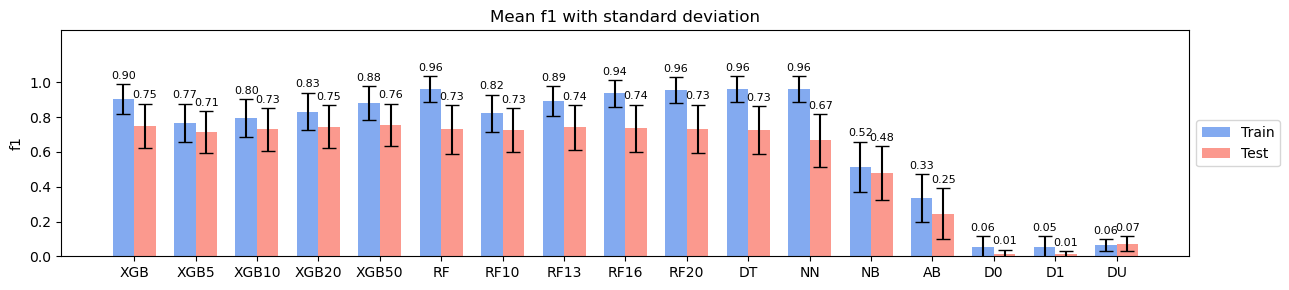

In [12]:
for mn in ml_metrics_names:
    if "train" in mn:
        mn_train = mn
        mn_test = mn.replace("train", "test")

        # Data for the two series
        train_means = metrics_mean[mn_train]
        test_means  = metrics_mean[mn_test]
        train_stds  = metrics_std[mn_train]
        test_stds   = metrics_std[mn_test]

        x = np.arange(len(model_names_short))   # positions
        width = 0.35

        plt.figure(figsize=(figsize_x, figsize_y))

        # Two bar groups
        plt.bar(x - width/2, train_means, width,
                yerr=train_stds, capsize=5,
                label='Train', color='cornflowerblue', alpha=0.8)

        plt.bar(x + width/2, test_means, width,
                yerr=test_stds, capsize=5,
                label='Test', color='salmon', alpha=0.8)

        # Labels & layout
        plt.xticks(x, model_names_short)
        title = mn.replace(" (train)", "")
        ylabel = re.sub(r"\([^)]*\)", "", title).strip()
        plt.ylabel(ylabel)
        plt.title(f'Mean {transform_transpose_text(title)} with standard deviation')

        if "time" not in mn:
            plt.ylim(ylim_a, ylim_b)
            ax = plt.gca()
            ticks = ax.get_yticks()
            ax.set_yticks([t for t in ticks if t <= 1])

        # Add mean value labels above bars
        for i, (mean, std) in enumerate(zip(train_means, train_stds)):
            plt.text(x[i] - width/2, mean + std + 0.03, f"{mean:.2f}",
                    ha='center', fontsize=fontsize)

        for i, (mean, std) in enumerate(zip(test_means, test_stds)):
            plt.text(x[i] + width/2, mean + std + 0.03, f"{mean:.2f}",
                    ha='center', fontsize=fontsize)

        os.makedirs(plots_dir, exist_ok=True)

        plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
        plt.tight_layout()

        plt.savefig(os.path.join(plots_dir, f"{transform_transpose_text(title)} (single label).png"),
            dpi=300, bbox_inches="tight")
        plt.show()